# 🌧️ Rainfall Prediction — Combined ML + Deep Learning Pipeline

This notebook merges two source notebooks into one end-to-end pipeline:

- **Data analysis & preprocessing** (EDA, class balancing, MICE imputation, outlier removal, feature selection)
- **6 classical ML models** (each in its own cell): Logistic Regression, Decision Tree, Random Forest, LightGBM, CatBoost, XGBoost
- **2 deep learning models**: a feed-forward **ANN (DNN)** and an **LSTM**, built in PyTorch
- **All 8 trained models are saved to disk** along with the scaler / encoders needed to reproduce preprocessing
- A final cell that **writes a ready-to-run Streamlit app** (`app.py`) which loads all 8 saved models and lets you get predictions from a simple web UI

> **Before running:** place `weatherAUS.csv` in the same folder as this notebook (or update `DATA_PATH` below). Dataset: [Rain in Australia (Kaggle)](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package).


In [10]:
# Install any missing dependencies (safe to re-run)
import sys, subprocess

def _pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["lightgbm", "catboost", "xgboost", "torch", "tqdm", "joblib"]:
    try:
        __import__(pkg if pkg != "xgboost" else "xgboost")
    except ImportError:
        _pip_install(pkg)


In [40]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline

from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, SelectFromModel
from sklearn.metrics import (accuracy_score, roc_auc_score, cohen_kappa_score,roc_curve, classification_report, ConfusionMatrixDisplay)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Where trained models & preprocessing artifacts will be saved
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Libraries imported successfully!
PyTorch version: 2.11.0+cpu
Device: cpu


## 1. Load the Data

In [41]:
df = pd.read_csv(r"E:\Skill Development\Data Science\70 Days 70 Project\Rainfall Prediction Using Deep Learning Models\data\weatherAUS.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 2. Data Exploration

In [42]:
df.shape

(145460, 23)

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


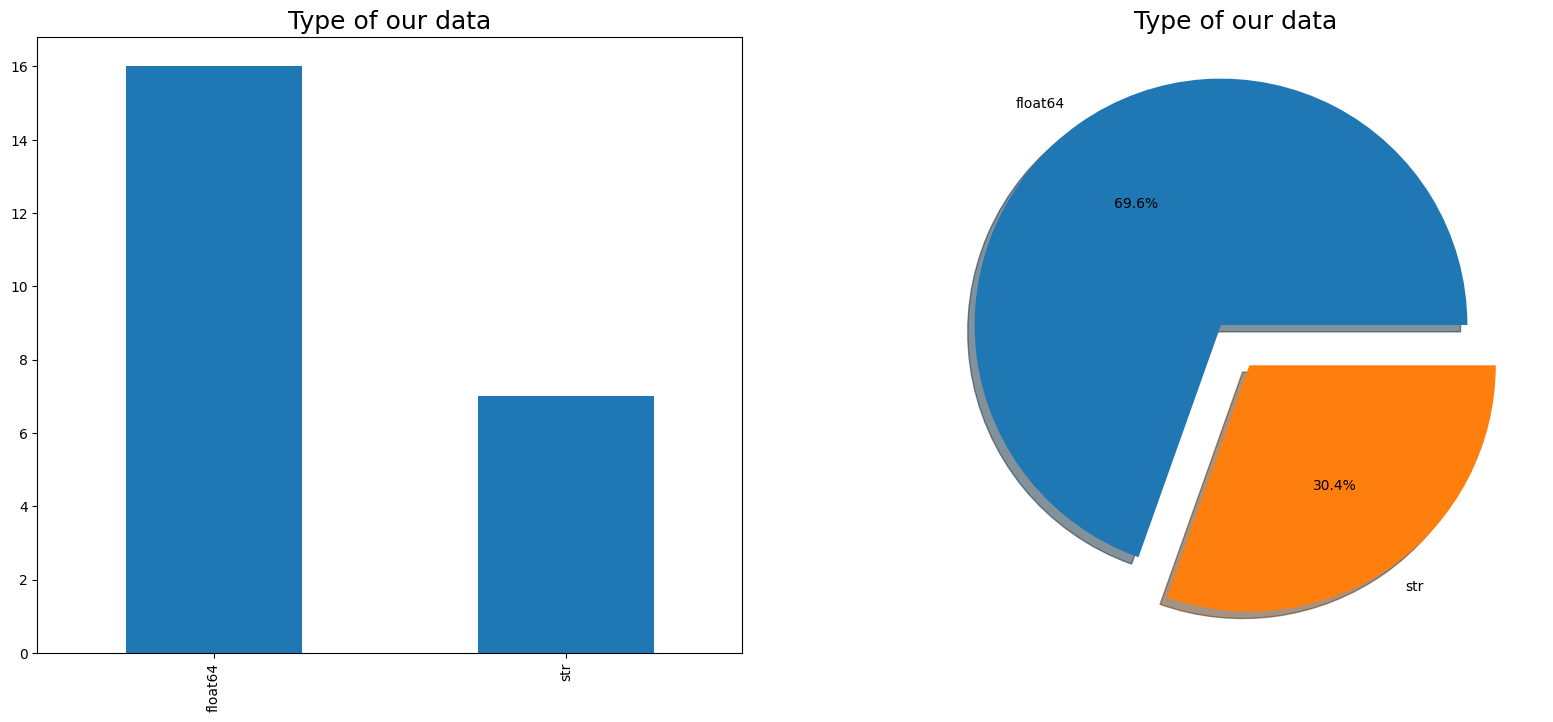

In [44]:
fig, axarr = plt.subplots(1, 2, figsize=(20, 8))

df.dtypes.value_counts().plot.pie(explode=[0.1, 0.1], autopct='%1.1f%%', shadow=True, ax=axarr[1])
axarr[1].set_title("Type of our data", fontsize=18)

df.dtypes.value_counts().plot(kind='bar', ax=axarr[0])
axarr[0].set_title("Type of our data", fontsize=18)
plt.show()


`RainToday` and `RainTomorrow` are Yes/No objects — convert them to binary (1/0).

In [45]:
print(df["RainToday"].value_counts(dropna=False))

RainToday
No     110319
Yes     31880
NaN      3261
Name: count, dtype: int64


In [46]:
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# 1) Remove rows that contain any NaN
df = df.dropna()

print(df['RainToday'].value_counts(dropna=False))
print(df['RainTomorrow'].value_counts(dropna=False))

RainToday
0.0    43958
1.0    12462
Name: count, dtype: int64
RainTomorrow
0.0    43993
1.0    12427
Name: count, dtype: int64


## 3. Class Imbalance

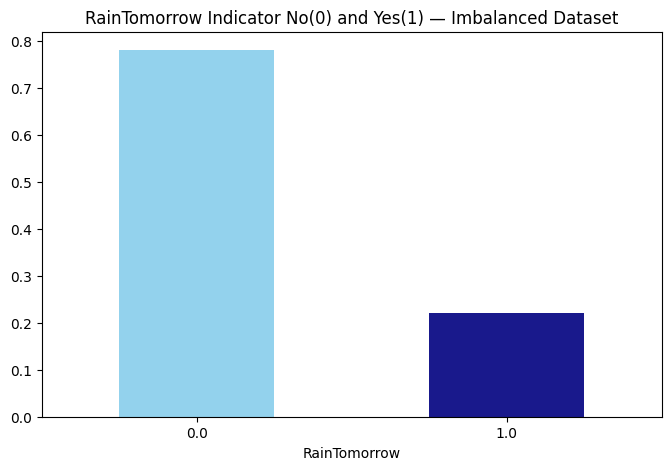

In [47]:
plt.figure(figsize=(8, 5))
df['RainTomorrow'].value_counts(normalize=True).plot(kind='bar', color=['skyblue', 'navy'], alpha=0.9, rot=0)
plt.title('RainTomorrow Indicator No(0) and Yes(1) — Imbalanced Dataset')
plt.show()


The classes are roughly 78:22, so we oversample the minority class to balance the dataset.

In [48]:
no = df[df.RainTomorrow == 0]
yes = df[df.RainTomorrow == 1]
print(f"Number of No RainTomorrow samples: {len(no)}")
print(f"Number of Yes RainTomorrow samples: {len(yes)}")

Number of No RainTomorrow samples: 43993
Number of Yes RainTomorrow samples: 12427


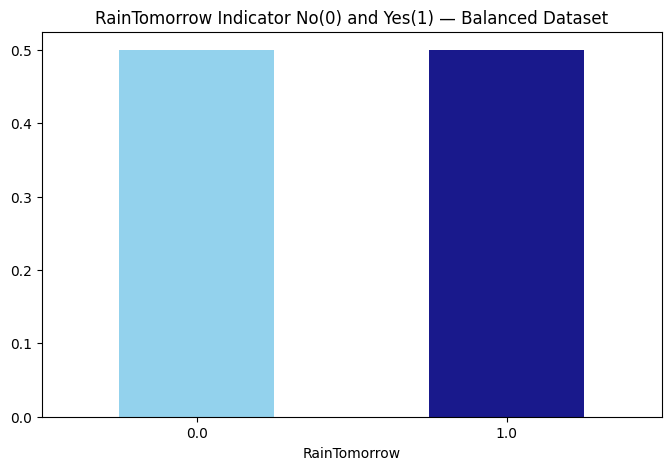

In [49]:

yes_oversampled = resample(yes, replace=True, n_samples=len(no), random_state=123)
oversampled = pd.concat([no, yes_oversampled])

plt.figure(figsize=(8, 5))
oversampled.RainTomorrow.value_counts(normalize=True).plot(kind='bar', color=['skyblue', 'navy'], alpha=0.9, rot=0)
plt.title('RainTomorrow Indicator No(0) and Yes(1) — Balanced Dataset')
plt.show()


## 4. Missing Data

In [50]:
missing_values = oversampled.isnull().sum()
percent_missing = oversampled.isnull().sum() / oversampled.shape[0] * 100
pd.DataFrame({'missing_values': missing_values, 'percent_missing %': percent_missing, 'data type': oversampled.dtypes})


,missing_values,percent_missing %,data type
Date,0,0.0,str
Location,0,0.0,str
MinTemp,0,0.0,float64
MaxTemp,0,0.0,float64
Rainfall,0,0.0,float64
Evaporation,0,0.0,float64
Sunshine,0,0.0,float64
WindGustDir,0,0.0,str
WindGustSpeed,0,0.0,float64
WindDir9am,0,0.0,str


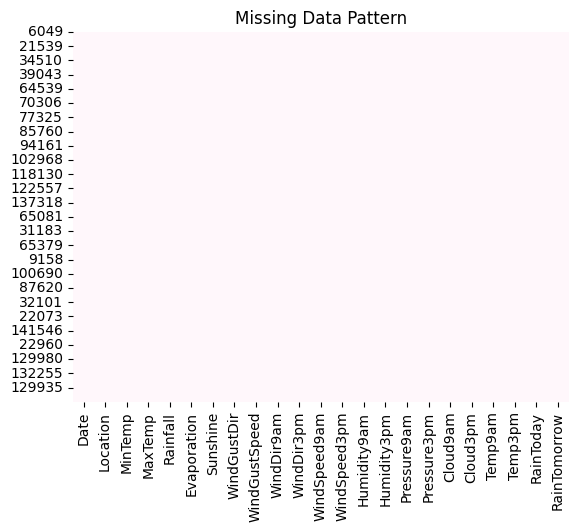

In [51]:
sns.heatmap(oversampled.isnull(), cbar=False, cmap='PuBu')
plt.title("Missing Data Pattern")
plt.show()


In [52]:
total = oversampled.isnull().sum().sort_values(ascending=False)
percent = (oversampled.isnull().sum() / oversampled.isnull().count()).sort_values(ascending=False)
pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).head(4)


,Total,Percent
Date,0,0.0
Location,0,0.0
MinTemp,0,0.0
MaxTemp,0,0.0


## 5. Imputation & Transformation

Categorical columns are imputed with the mode, then label-encoded. Remaining missing values are handled with
Multiple Imputation by Chained Equations (MICE). Outliers are then removed with the IQR method.

In [53]:
oversampled.select_dtypes(include=['object']).columns

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'], dtype='str')

In [54]:
for col in ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']:
    oversampled[col] = oversampled[col].fillna(oversampled[col].mode()[0])


In [55]:
# Convert categorical features to numeric with Label Encoding (encoders saved for reuse in the app)
lencoders = {}
for col in oversampled.select_dtypes(include=['object']).columns:
    lencoders[col] = LabelEncoder()
    oversampled[col] = lencoders[col].fit_transform(oversampled[col])

joblib.dump(lencoders, os.path.join(MODEL_DIR, "label_encoders.joblib"))
list(lencoders.keys())


['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

In [56]:
# Multiple Imputation by Chained Equations
MiceImputed = oversampled.copy(deep=True)
mice_imputer = IterativeImputer(random_state=0)
MiceImputed.iloc[:, :] = mice_imputer.fit_transform(oversampled)
MiceImputed.shape


(87986, 23)

In [57]:
Q1 = MiceImputed.quantile(0.25)
Q3 = MiceImputed.quantile(0.75)
IQR = Q3 - Q1
IQR


Date             1437.0
Location           12.0
MinTemp            10.1
MaxTemp            11.1
Rainfall            2.2
Evaporation         4.4
Sunshine            6.8
WindGustDir         9.0
WindGustSpeed      19.0
WindDir9am          8.0
WindDir3pm          9.0
WindSpeed9am       11.0
WindSpeed3pm       13.0
Humidity9am        25.0
Humidity3pm        29.0
Pressure9am         9.5
Pressure3pm         9.6
Cloud9am            5.0
Cloud3pm            4.0
Temp9am            10.3
Temp3pm            10.5
RainToday           1.0
RainTomorrow        1.0
dtype: float64

In [58]:
MiceImputed = MiceImputed[~((MiceImputed < (Q1 - 1.5 * IQR)) | (MiceImputed > (Q3 + 1.5 * IQR))).any(axis=1)]
MiceImputed.shape


(68430, 23)

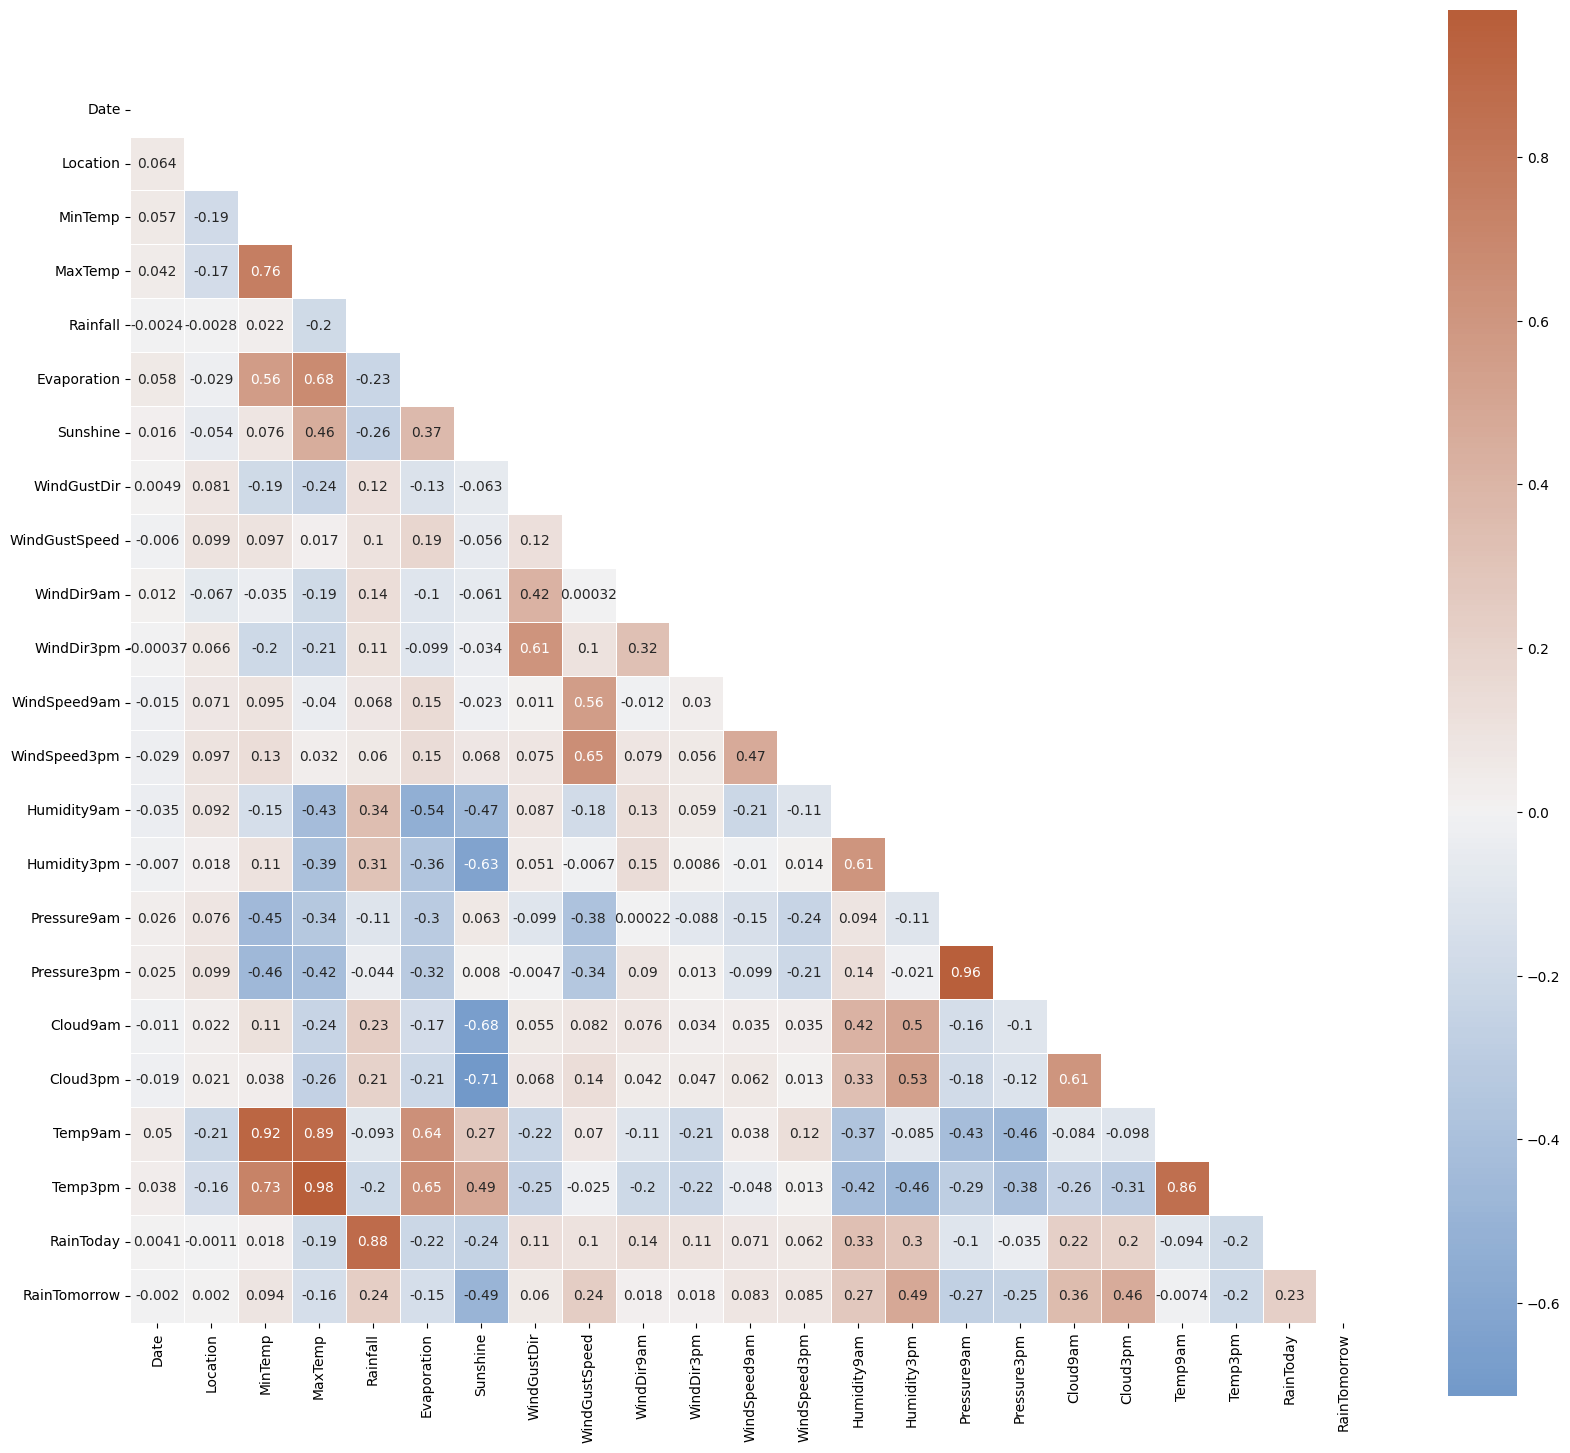

In [59]:
corr = MiceImputed.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(20, 20))
cmap = sns.diverging_palette(250, 25, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, square=True, annot=True, linewidths=.5, cbar_kws={"shrink": .9})
plt.show()


## 6. Feature Selection

In [60]:
# Filter method (Chi-Square) — data must be non-negative, so use MinMaxScaler here
r_scaler = MinMaxScaler()
modified_data = pd.DataFrame(r_scaler.fit_transform(MiceImputed), index=MiceImputed.index, columns=MiceImputed.columns)

X_chi = modified_data.loc[:, modified_data.columns != 'RainTomorrow']
y_chi = modified_data['RainTomorrow']
selector = SelectKBest(chi2, k=10)
selector.fit(X_chi, y_chi)
print("Top-10 features (chi-square):", list(X_chi.columns[selector.get_support(indices=True)]))


Top-10 features (chi-square): ['Rainfall', 'Sunshine', 'WindGustSpeed', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'RainToday']


In [61]:
# Wrapper method (Random Forest importance)
from sklearn.ensemble import RandomForestClassifier as _RF
X_wrap = MiceImputed.drop('RainTomorrow', axis=1)
y_wrap = MiceImputed['RainTomorrow']
rf_selector = SelectFromModel(_RF(n_estimators=100, random_state=0))
rf_selector.fit(X_wrap, y_wrap)
print("Selected features (RF importance):", list(X_wrap.loc[:, rf_selector.get_support()].columns))


Selected features (RF importance): ['Sunshine', 'WindGustSpeed', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud3pm']


## 7. Train / Test Split & Scaling

We use the same feature set, split, and scaler for **all 8 models** so predictions stay consistent between the notebook and the Streamlit app.

In [62]:
FEATURE_COLUMNS = ['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir',
                    'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
                    'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm',
                    'RainToday']

X = MiceImputed[FEATURE_COLUMNS]
y = MiceImputed['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # fit ONLY on train, then transform test

joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.joblib"))
joblib.dump(FEATURE_COLUMNS, os.path.join(MODEL_DIR, "feature_columns.joblib"))

print(f"Train shape: {X_train_scaled.shape} | Test shape: {X_test_scaled.shape}")


Train shape: (51322, 21) | Test shape: (17108, 21)


## 8. Helper Functions

In [63]:
def plot_roc_cur(fper, tper, label):
    plt.plot(fper, tper, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {label}')
    plt.legend()
    plt.show()


In [64]:
results = {}  # collects metrics for every model, used in the final comparison

def run_model(model, name, X_train, y_train, X_test, y_test, save_path=None, fit_kwargs=None):
    fit_kwargs = fit_kwargs or {}
    t0 = time.time()
    model.fit(X_train, y_train, **fit_kwargs)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    coh_kap = cohen_kappa_score(y_test, y_pred)
    time_taken = time.time() - t0

    print(f"=== {name} ===")
    print(f"Accuracy       = {accuracy:.4f}")
    print(f"ROC AUC        = {roc_auc:.4f}")
    print(f"Cohen's Kappa  = {coh_kap:.4f}")
    print(f"Time taken (s) = {time_taken:.2f}")
    print(classification_report(y_test, y_pred, digits=4))

    probs = model.predict_proba(X_test)[:, 1]
    fper, tper, _ = roc_curve(y_test, probs)
    plot_roc_cur(fper, tper, name)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='all', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    results[name] = {'accuracy': accuracy, 'roc_auc': roc_auc, 'cohen_kappa': coh_kap, 'time_taken': time_taken}

    if save_path:
        joblib.dump(model, save_path)
        print(f"Saved model to {save_path}")

    return model


## 9. Model 1/8 — Logistic Regression

=== Logistic Regression ===
Accuracy       = 0.7872
ROC AUC        = 0.7810
Cohen's Kappa  = 0.5655
Time taken (s) = 1.05
              precision    recall  f1-score   support

         0.0     0.7969    0.8324    0.8143      9586
         1.0     0.7735    0.7297    0.7510      7522

    accuracy                         0.7872     17108
   macro avg     0.7852    0.7810    0.7826     17108
weighted avg     0.7867    0.7872    0.7864     17108



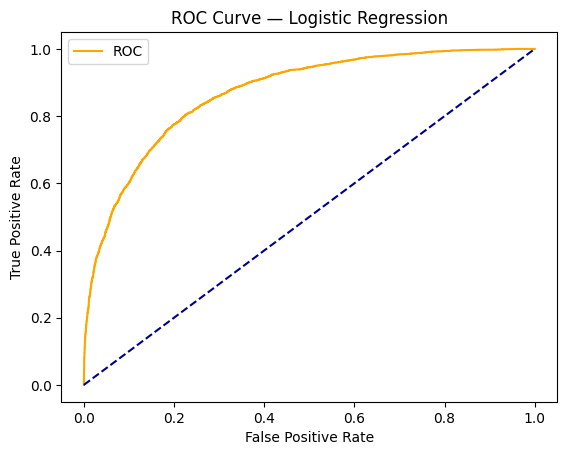

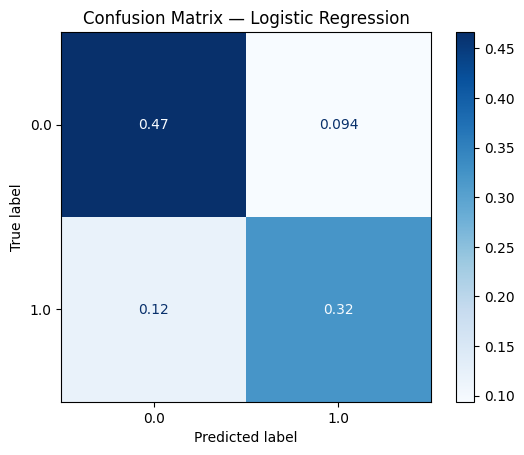

Saved model to models\model_lr.joblib


In [65]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(penalty='l1', solver='liblinear', random_state=12345)
model_lr = run_model(model_lr, "Logistic Regression", X_train_scaled, y_train, X_test_scaled, y_test,
                      save_path=os.path.join(MODEL_DIR, "model_lr.joblib"))


## 10. Model 2/8 — Decision Tree

=== Decision Tree ===
Accuracy       = 0.8761
ROC AUC        = 0.8804
Cohen's Kappa  = 0.7517
Time taken (s) = 0.28
              precision    recall  f1-score   support

         0.0     0.9277    0.8448    0.8843      9586
         1.0     0.8224    0.9161    0.8667      7522

    accuracy                         0.8761     17108
   macro avg     0.8751    0.8804    0.8755     17108
weighted avg     0.8814    0.8761    0.8766     17108



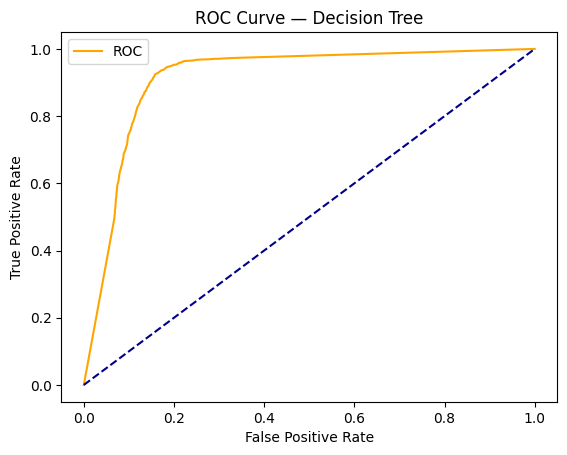

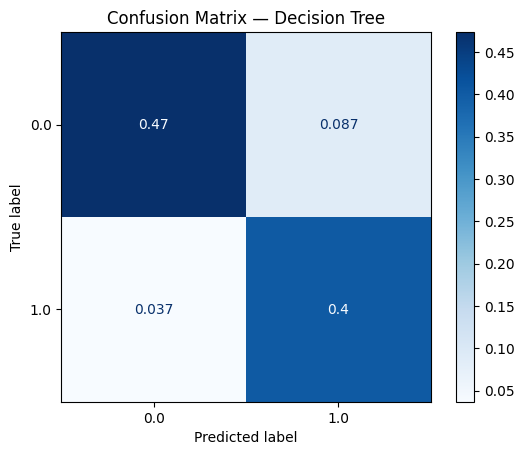

Saved model to models\model_dt.joblib


In [66]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=16, max_features="sqrt", random_state=12345)
model_dt = run_model(model_dt, "Decision Tree", X_train_scaled, y_train, X_test_scaled, y_test,
                      save_path=os.path.join(MODEL_DIR, "model_dt.joblib"))


## 11. Model 3/8 — Random Forest

=== Random Forest ===
Accuracy       = 0.9329
ROC AUC        = 0.9361
Cohen's Kappa  = 0.8649
Time taken (s) = 12.45
              precision    recall  f1-score   support

         0.0     0.9688    0.9096    0.9382      9586
         1.0     0.8931    0.9626    0.9266      7522

    accuracy                         0.9329     17108
   macro avg     0.9309    0.9361    0.9324     17108
weighted avg     0.9355    0.9329    0.9331     17108



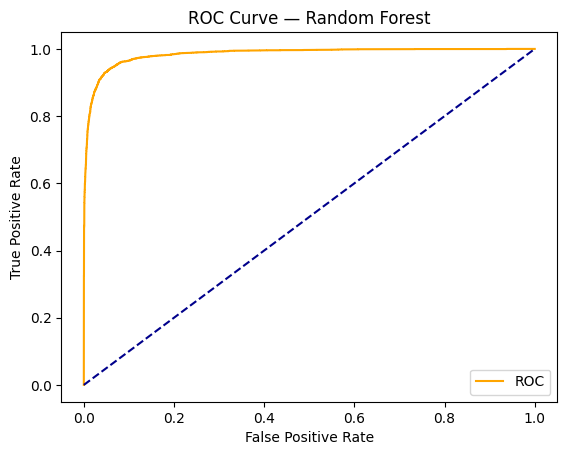

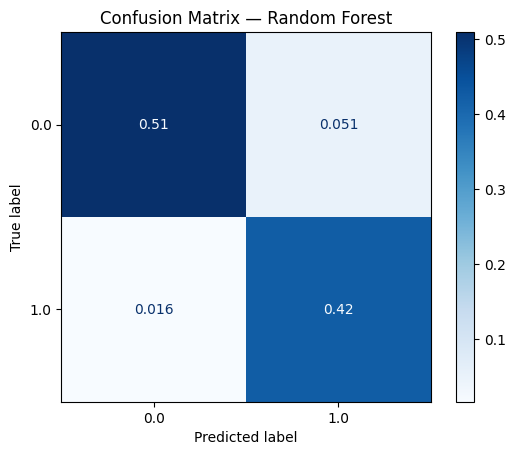

Saved model to models\model_rf.joblib


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(max_depth=16, min_samples_leaf=1, min_samples_split=2,
                                   n_estimators=2500, random_state=12345)
model_rf = run_model(model_rf, "Random Forest", X_train_scaled, y_train, X_test_scaled, y_test,
                      save_path=os.path.join(MODEL_DIR, "model_rf.joblib"))


## 12. Model 4/8 — LightGBM

=== LightGBM ===
Accuracy       = 0.8736
ROC AUC        = 0.8739
Cohen's Kappa  = 0.7446
Time taken (s) = 4.26
              precision    recall  f1-score   support

         0.0     0.8996    0.8718    0.8855      9586
         1.0     0.8428    0.8760    0.8591      7522

    accuracy                         0.8736     17108
   macro avg     0.8712    0.8739    0.8723     17108
weighted avg     0.8746    0.8736    0.8739     17108



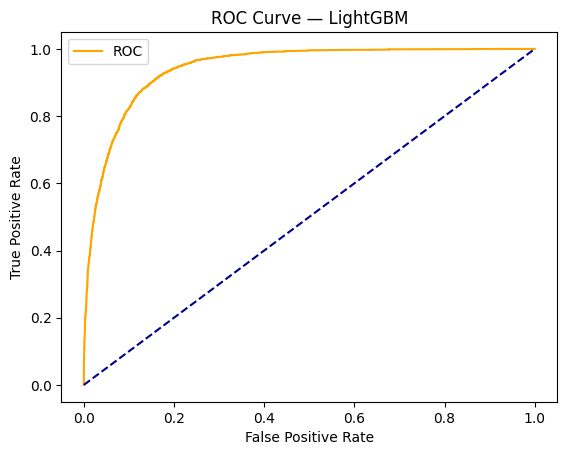

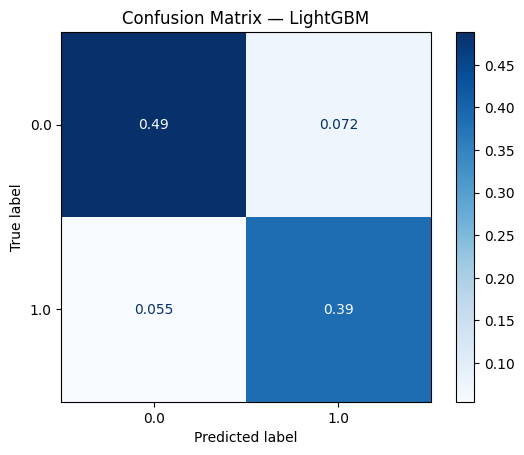

Saved model to models\model_lgb.joblib


In [ ]:
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(colsample_bytree=0.95, max_depth=16, min_split_gain=0.1, n_estimators=2500,
                                num_leaves=50, reg_alpha=1.2, reg_lambda=1.2, subsample=0.95,
                                subsample_freq=20, random_state=12345, verbose=-1)
model_lgb = run_model(model_lgb, "LightGBM", X_train_scaled, y_train, X_test_scaled, y_test,
                       save_path=os.path.join(MODEL_DIR, "model_lgb.joblib"))


## 13. Model 5/8 — CatBoost

=== CatBoost ===
Accuracy       = 0.9318
ROC AUC        = 0.9352
Cohen's Kappa  = 0.8628
Time taken (s) = 16.83
              precision    recall  f1-score   support

         0.0     0.9691    0.9072    0.9371      9586
         1.0     0.8906    0.9632    0.9255      7522

    accuracy                         0.9318     17108
   macro avg     0.9299    0.9352    0.9313     17108
weighted avg     0.9346    0.9318    0.9320     17108



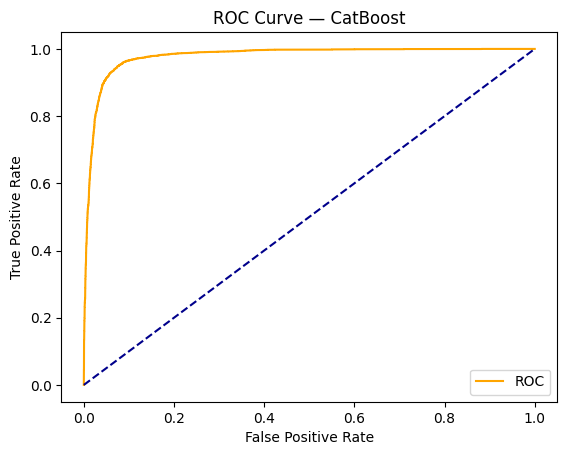

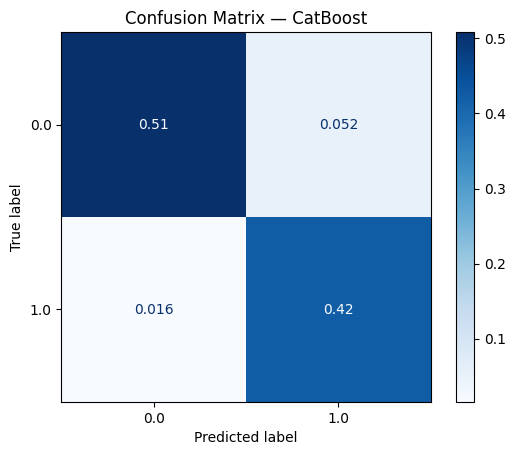

Saved model to models\model_cb.joblib


In [ ]:
import catboost as cb

model_cb = cb.CatBoostClassifier(iterations=2500, max_depth=10, random_state=12345, verbose=False)
model_cb = run_model(model_cb, "CatBoost", X_train_scaled, y_train, X_test_scaled, y_test,
                      save_path=os.path.join(MODEL_DIR, "model_cb.joblib"))


## 14. Model 6/8 — XGBoost

=== XGBoost ===
Accuracy       = 0.9451
ROC AUC        = 0.9481
Cohen's Kappa  = 0.8895
Time taken (s) = 6.55
              precision    recall  f1-score   support

         0.0     0.9778    0.9230    0.9496      9586
         1.0     0.9084    0.9733    0.9397      7522

    accuracy                         0.9451     17108
   macro avg     0.9431    0.9481    0.9447     17108
weighted avg     0.9473    0.9451    0.9453     17108



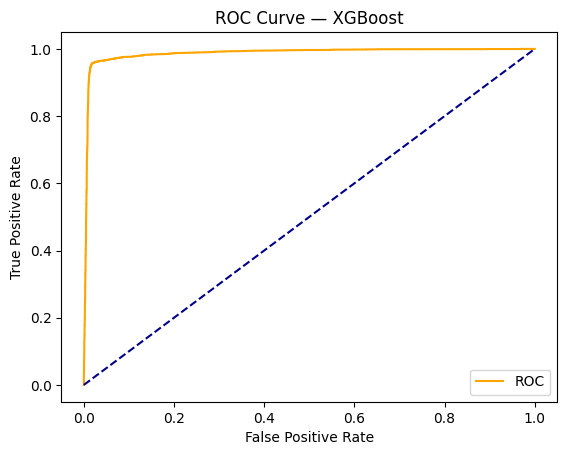

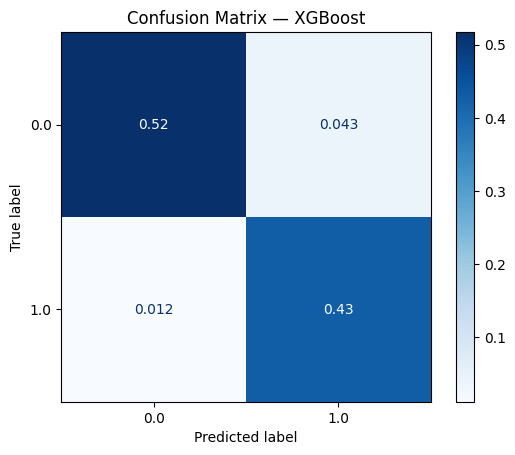

Saved model to models\model_xgb.joblib


In [ ]:
import xgboost as xgb

model_xgb = xgb.XGBClassifier(n_estimators=2500, max_depth=10, random_state=12345,
                               use_label_encoder=False, eval_metric='logloss')
model_xgb = run_model(model_xgb, "XGBoost", X_train_scaled, y_train, X_test_scaled, y_test,
                       save_path=os.path.join(MODEL_DIR, "model_xgb.joblib"))


## 15. Classical ML Model Comparison (so far: 6 models)

In [71]:
ml_comparison = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
ml_comparison


,Model,accuracy,roc_auc,cohen_kappa,time_taken
0,Logistic Regression,0.787234,0.781043,0.565534,1.054138
1,Decision Tree,0.876140,0.880443,0.751667,0.281510
2,Random Forest,0.932897,0.936099,0.864944,12.448887
3,LightGBM,0.873626,0.873878,0.744602,4.260050
4,CatBoost,0.931786,0.935165,0.862762,16.833075
5,XGBoost,0.945113,0.948146,0.889455,6.554375


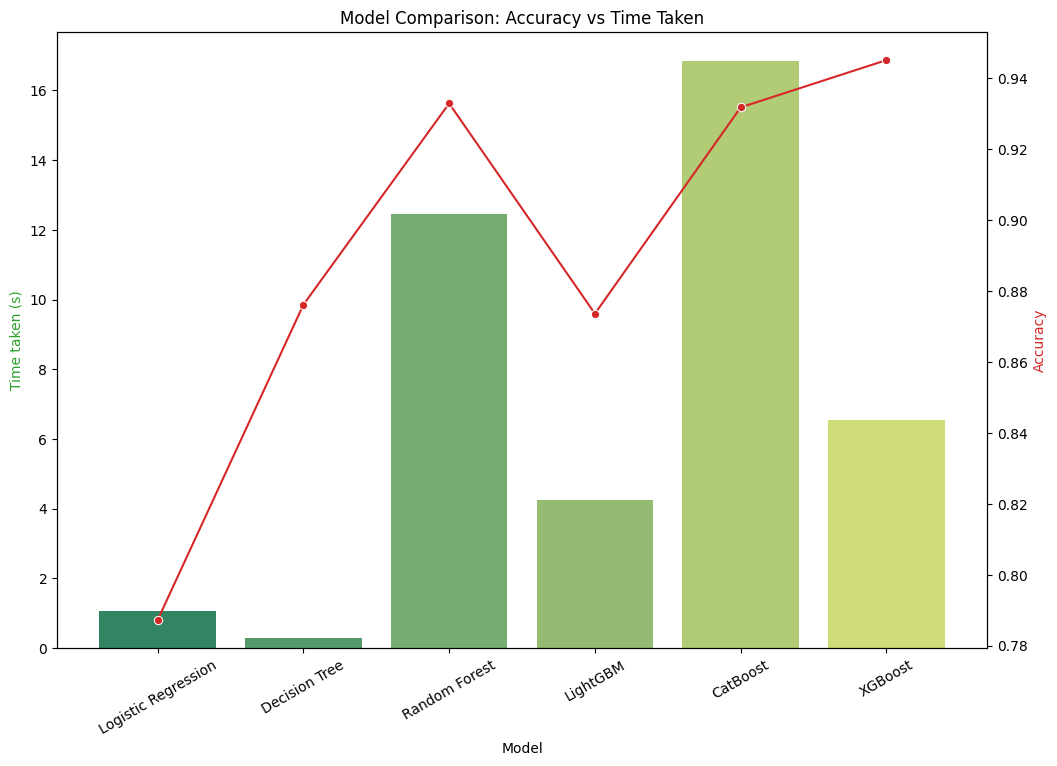

In [72]:
fig, ax1 = plt.subplots(figsize=(12, 8))
color = 'tab:green'
ax1.set_xlabel('Model')
ax1.set_ylabel('Time taken (s)', color=color)
sns.barplot(x='Model', y='time_taken', data=ml_comparison, palette='summer', ax=ax1)
ax1.tick_params(axis='x', rotation=30)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Accuracy', color=color)
sns.lineplot(x='Model', y='accuracy', data=ml_comparison, sort=False, color=color, marker='o', ax=ax2)
plt.title('Model Comparison: Accuracy vs Time Taken')
plt.show()


## 16. Preparing Data for the Neural Networks (ANN + LSTM)

Both deep learning models reuse the exact same scaled train/test split as the classical models above, so all 8 models are directly comparable.

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

BATCH_SIZE = 64
NUM_EPOCHS = 120  # increase for better performance, at the cost of longer training time

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train batches: 802 | Test batches: 268


In [74]:
def evaluate_torch_model(model, name, loader, save_path=None):
    model.eval()
    all_preds, all_labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    time_taken = time.time() - t0

    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()

    accuracy = accuracy_score(all_labels, all_preds)
    roc_auc = roc_auc_score(all_labels, all_preds)
    coh_kap = cohen_kappa_score(all_labels, all_preds)

    print(f"=== {name} ===")
    print(f"Accuracy       = {accuracy:.4f}")
    print(f"ROC AUC        = {roc_auc:.4f}")
    print(f"Cohen's Kappa  = {coh_kap:.4f}")
    print(classification_report(all_labels, all_preds, target_names=['No Rain', 'Rain'], digits=4))

    results[name] = {'accuracy': accuracy, 'roc_auc': roc_auc, 'cohen_kappa': coh_kap, 'time_taken': time_taken}

    if save_path:
        torch.save(model.state_dict(), save_path)
        print(f"Saved model weights to {save_path}")


## 17. Model 7/8 — ANN (Deep Neural Network)

In [75]:
class RainfallDNN(nn.Module):
    def __init__(self, input_size):
        super(RainfallDNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.drop2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.drop3 = nn.Dropout(0.3)

        self.out = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x)); x = self.bn1(x); x = self.drop1(x)
        x = torch.relu(self.fc2(x)); x = self.bn2(x); x = self.drop2(x)
        x = torch.relu(self.fc3(x)); x = self.bn3(x); x = self.drop3(x)
        x = torch.sigmoid(self.out(x))
        return x

dnn_model = RainfallDNN(input_size=X_train_scaled.shape[1]).to(device)
print(dnn_model)
print(f"Total parameters: {sum(p.numel() for p in dnn_model.parameters()):,}")


RainfallDNN(
  (fc1): Linear(in_features=21, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.3, inplace=False)
  (out): Linear(in_features=32, out_features=1, bias=True)
)
Total parameters: 13,633


In [76]:
dnn_criterion = nn.BCELoss()
dnn_optimizer = optim.Adam(dnn_model.parameters(), lr=0.001, weight_decay=1e-5)


In [77]:
for epoch in range(NUM_EPOCHS):
    dnn_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"DNN Epoch {epoch+1}/{NUM_EPOCHS}"):
        inputs, labels = inputs.to(device), labels.to(device)
        dnn_optimizer.zero_grad()
        outputs = dnn_model(inputs)
        loss = dnn_criterion(outputs, labels)
        loss.backward()
        dnn_optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        preds = (outputs >= 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    if (epoch + 1) % 5 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {train_loss/train_total:.4f} | "
              f"Train Acc: {100*train_correct/train_total:.2f}%")

print("DNN training completed!")


DNN Epoch 5/15: 100%|██████████| 802/802 [00:04<00:00, 169.36it/s]


Epoch [5/15] Train Loss: 0.4324 | Train Acc: 79.70%


DNN Epoch 10/15: 100%|██████████| 802/802 [00:08<00:00, 99.05it/s] 


Epoch [10/15] Train Loss: 0.4208 | Train Acc: 80.30%


DNN Epoch 15/15: 100%|██████████| 802/802 [00:09<00:00, 82.01it/s] 

Epoch [15/15] Train Loss: 0.4151 | Train Acc: 80.75%
DNN training completed!


In [78]:
evaluate_torch_model(dnn_model, "ANN (DNN)", test_loader, save_path=os.path.join(MODEL_DIR, "dnn_model.pth"))


=== ANN (DNN) ===
Accuracy       = 0.8113
ROC AUC        = 0.8082
Cohen's Kappa  = 0.6168
              precision    recall  f1-score   support

     No Rain     0.8302    0.8338    0.8320      9586
        Rain     0.7870    0.7826    0.7848      7522

    accuracy                         0.8113     17108
   macro avg     0.8086    0.8082    0.8084     17108
weighted avg     0.8112    0.8113    0.8113     17108

Saved model weights to models\dnn_model.pth


## 18. Model 8/8 — LSTM

In [79]:
class RainfallLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super(RainfallLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=1,  # each feature is treated as one timestep
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.unsqueeze(2)  # (batch, features) -> (batch, features, 1)
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]
        x = self.fc1(x); x = self.relu(x); x = self.dropout(x)
        x = self.fc2(x); x = self.sigmoid(x)
        return x

lstm_model = RainfallLSTM(input_size=X_train_scaled.shape[1]).to(device)
print(lstm_model)
print(f"Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")


RainfallLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Total parameters: 52,545


In [80]:
lstm_criterion = nn.BCELoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)


In [81]:
for epoch in range(NUM_EPOCHS):
    lstm_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"LSTM Epoch {epoch+1}/{NUM_EPOCHS}"):
        inputs, labels = inputs.to(device), labels.to(device)
        lstm_optimizer.zero_grad()
        outputs = lstm_model(inputs)
        loss = lstm_criterion(outputs, labels)
        loss.backward()
        lstm_optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        preds = (outputs >= 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    if (epoch + 1) % 5 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {train_loss/train_total:.4f} | "
              f"Train Acc: {100*train_correct/train_total:.2f}%")

print("LSTM training completed!")


LSTM Epoch 5/15: 100%|██████████| 802/802 [00:21<00:00, 38.12it/s]


Epoch [5/15] Train Loss: 0.4655 | Train Acc: 77.75%


LSTM Epoch 10/15: 100%|██████████| 802/802 [00:31<00:00, 25.68it/s]


Epoch [10/15] Train Loss: 0.4364 | Train Acc: 79.45%


LSTM Epoch 15/15: 100%|██████████| 802/802 [00:27<00:00, 29.69it/s]

Epoch [15/15] Train Loss: 0.4022 | Train Acc: 81.28%
LSTM training completed!


In [82]:
evaluate_torch_model(lstm_model, "LSTM", test_loader, save_path=os.path.join(MODEL_DIR, "lstm_model.pth"))


=== LSTM ===
Accuracy       = 0.8031
ROC AUC        = 0.8006
Cohen's Kappa  = 0.6007
              precision    recall  f1-score   support

     No Rain     0.8266    0.8208    0.8237      9586
        Rain     0.7736    0.7805    0.7770      7522

    accuracy                         0.8031     17108
   macro avg     0.8001    0.8006    0.8004     17108
weighted avg     0.8033    0.8031    0.8032     17108

Saved model weights to models\lstm_model.pth


## 19. Final Comparison — All 8 Models

In [83]:
final_comparison = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
final_comparison = final_comparison.sort_values('accuracy', ascending=False).reset_index(drop=True)
final_comparison


,Model,accuracy,roc_auc,cohen_kappa,time_taken
0,XGBoost,0.945113,0.948146,0.889455,6.554375
1,Random Forest,0.932897,0.936099,0.864944,12.448887
2,CatBoost,0.931786,0.935165,0.862762,16.833075
3,Decision Tree,0.876140,0.880443,0.751667,0.281510
4,LightGBM,0.873626,0.873878,0.744602,4.260050
5,ANN (DNN),0.811316,0.808229,0.616829,1.382446
6,LSTM,0.803075,0.800645,0.600715,2.028741
7,Logistic Regression,0.787234,0.781043,0.565534,1.054138


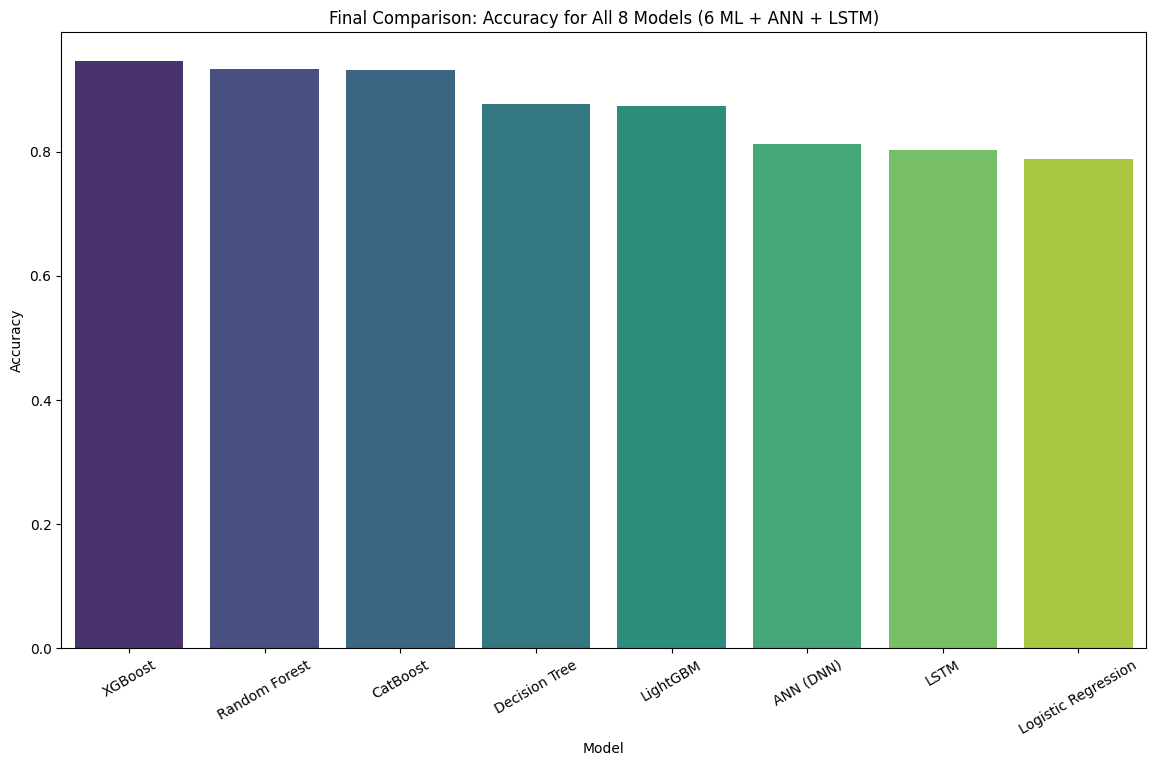

In [84]:
fig, ax1 = plt.subplots(figsize=(14, 8))
sns.barplot(x='Model', y='accuracy', data=final_comparison, palette='viridis', ax=ax1)
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Model')
ax1.tick_params(axis='x', rotation=30)
plt.title('Final Comparison: Accuracy for All 8 Models (6 ML + ANN + LSTM)')
plt.show()


## 20. Save Preprocessing Artifacts

(The scaler, label encoders, and feature column order were already saved as we went; this cell just confirms everything needed by the Streamlit app is present.)

In [85]:
required_files = [
    "model_lr.joblib", "model_dt.joblib", "model_rf.joblib", "model_lgb.joblib",
    "model_cb.joblib", "model_xgb.joblib", "dnn_model.pth", "lstm_model.pth",
    "scaler.joblib", "label_encoders.joblib", "feature_columns.joblib",
]
for f in required_files:
    path = os.path.join(MODEL_DIR, f)
    print(f"{'OK ' if os.path.exists(path) else 'MISSING'}  {path}")


OK   models\model_lr.joblib
OK   models\model_dt.joblib
OK   models\model_rf.joblib
OK   models\model_lgb.joblib
OK   models\model_cb.joblib
OK   models\model_xgb.joblib
OK   models\dnn_model.pth
OK   models\lstm_model.pth
OK   models\scaler.joblib
OK   models\label_encoders.joblib
OK   models\feature_columns.joblib


## 21. Streamlit App — Rainfall Prediction Website

Running the cell below writes a complete, ready-to-run `app.py`. Copy the printed code into your own `app.py`
(or just keep the generated file) and launch it with:

```bash
streamlit run app.py
```

Make sure the `models/` folder (with all 8 saved models + `scaler.joblib` + `label_encoders.joblib` +
`feature_columns.joblib`) sits next to `app.py`.


In [86]:
%%writefile app.py
"""
Rainfall Prediction — Streamlit App
Loads all 8 trained models (6 classical ML + ANN + LSTM) and returns a rain/no-rain
prediction (with probability) for user-entered weather conditions.

Run with:  streamlit run app.py
"""

import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st
import torch
import torch.nn as nn

MODEL_DIR = "models"

# ----------------------------------------------------------------------------
# Model architectures (must match training notebook exactly to load state_dicts)
# ----------------------------------------------------------------------------
class RainfallDNN(nn.Module):
    def __init__(self, input_size):
        super(RainfallDNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.drop3 = nn.Dropout(0.3)
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x)); x = self.bn1(x); x = self.drop1(x)
        x = torch.relu(self.fc2(x)); x = self.bn2(x); x = self.drop2(x)
        x = torch.relu(self.fc3(x)); x = self.bn3(x); x = self.drop3(x)
        return torch.sigmoid(self.out(x))


class RainfallLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super(RainfallLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.unsqueeze(2)
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]
        x = self.fc1(x); x = self.relu(x); x = self.dropout(x)
        x = self.fc2(x)
        return self.sigmoid(x)


# ----------------------------------------------------------------------------
# Cached loaders — everything loads once per session
# ----------------------------------------------------------------------------
@st.cache_resource
def load_artifacts():
    scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.joblib"))
    lencoders = joblib.load(os.path.join(MODEL_DIR, "label_encoders.joblib"))
    feature_columns = joblib.load(os.path.join(MODEL_DIR, "feature_columns.joblib"))
    return scaler, lencoders, feature_columns


@st.cache_resource
def load_ml_models():
    names = ["lr", "dt", "rf", "lgb", "cb", "xgb"]
    return {n: joblib.load(os.path.join(MODEL_DIR, f"model_{n}.joblib")) for n in names}


@st.cache_resource
def load_dl_models(input_size):
    dnn = RainfallDNN(input_size)
    dnn.load_state_dict(torch.load(os.path.join(MODEL_DIR, "dnn_model.pth"), map_location="cpu"))
    dnn.eval()

    lstm = RainfallLSTM(input_size)
    lstm.load_state_dict(torch.load(os.path.join(MODEL_DIR, "lstm_model.pth"), map_location="cpu"))
    lstm.eval()
    return dnn, lstm


MODEL_DISPLAY_NAMES = {
    "lr": "Logistic Regression", "dt": "Decision Tree", "rf": "Random Forest",
    "lgb": "LightGBM", "cb": "CatBoost", "xgb": "XGBoost",
    "ANN (DNN)": "ANN (Deep Neural Network)", "LSTM": "LSTM",
}


def build_input_dataframe(raw_inputs, feature_columns, lencoders):
    row = {}
    for col in feature_columns:
        val = raw_inputs[col]
        if col in lencoders:  # categorical -> encode with the saved LabelEncoder
            val = lencoders[col].transform([val])[0]
        row[col] = val
    return pd.DataFrame([row], columns=feature_columns)


# ----------------------------------------------------------------------------
# UI
# ----------------------------------------------------------------------------
st.set_page_config(page_title="Rainfall Prediction", page_icon="🌧️", layout="wide")
st.title("🌧️ Rainfall Prediction — Will it rain tomorrow?")
st.write("Enter today's weather conditions and compare predictions from all 8 trained models.")

scaler, lencoders, feature_columns = load_artifacts()
ml_models = load_ml_models()
dnn_model, lstm_model = load_dl_models(input_size=len(feature_columns))

with st.form("weather_form"):
    col1, col2, col3 = st.columns(3)

    with col1:
        location = st.selectbox("Location", sorted(lencoders["Location"].classes_))
        min_temp = st.number_input("MinTemp (°C)", value=15.0)
        max_temp = st.number_input("MaxTemp (°C)", value=25.0)
        rainfall = st.number_input("Rainfall today (mm)", value=0.0, min_value=0.0)
        evaporation = st.number_input("Evaporation (mm)", value=5.0, min_value=0.0)
        sunshine = st.number_input("Sunshine (hours)", value=7.0, min_value=0.0, max_value=24.0)
        rain_today = st.selectbox("Rain today?", ["No", "Yes"])

    with col2:
        wind_gust_dir = st.selectbox("WindGustDir", sorted(lencoders["WindGustDir"].classes_))
        wind_gust_speed = st.number_input("WindGustSpeed (km/h)", value=40.0, min_value=0.0)
        wind_dir_9am = st.selectbox("WindDir9am", sorted(lencoders["WindDir9am"].classes_))
        wind_dir_3pm = st.selectbox("WindDir3pm", sorted(lencoders["WindDir3pm"].classes_))
        wind_speed_9am = st.number_input("WindSpeed9am (km/h)", value=15.0, min_value=0.0)
        wind_speed_3pm = st.number_input("WindSpeed3pm (km/h)", value=20.0, min_value=0.0)

    with col3:
        humidity_9am = st.slider("Humidity9am (%)", 0, 100, 60)
        humidity_3pm = st.slider("Humidity3pm (%)", 0, 100, 50)
        pressure_9am = st.number_input("Pressure9am (hPa)", value=1015.0)
        pressure_3pm = st.number_input("Pressure3pm (hPa)", value=1013.0)
        cloud_9am = st.slider("Cloud9am (oktas)", 0, 9, 4)
        cloud_3pm = st.slider("Cloud3pm (oktas)", 0, 9, 4)
        temp_9am = st.number_input("Temp9am (°C)", value=18.0)
        temp_3pm = st.number_input("Temp3pm (°C)", value=23.0)

    submitted = st.form_submit_button("Predict")

if submitted:
    raw_inputs = {
        "Location": location, "MinTemp": min_temp, "MaxTemp": max_temp, "Rainfall": rainfall,
        "Evaporation": evaporation, "Sunshine": sunshine, "WindGustDir": wind_gust_dir,
        "WindGustSpeed": wind_gust_speed, "WindDir9am": wind_dir_9am, "WindDir3pm": wind_dir_3pm,
        "WindSpeed9am": wind_speed_9am, "WindSpeed3pm": wind_speed_3pm, "Humidity9am": humidity_9am,
        "Humidity3pm": humidity_3pm, "Pressure9am": pressure_9am, "Pressure3pm": pressure_3pm,
        "Cloud9am": cloud_9am, "Cloud3pm": cloud_3pm, "Temp9am": temp_9am, "Temp3pm": temp_3pm,
        "RainToday": 1 if rain_today == "Yes" else 0,
    }

    input_df = build_input_dataframe(raw_inputs, feature_columns, lencoders)
    scaled_input = scaler.transform(input_df)

    rows = []
    # 6 classical ML models
    for key, model in ml_models.items():
        pred = model.predict(scaled_input)[0]
        proba = model.predict_proba(scaled_input)[0][1]
        rows.append({"Model": MODEL_DISPLAY_NAMES[key], "Prediction": "Rain" if pred == 1 else "No Rain",
                     "Rain Probability": f"{proba:.1%}"})

    # ANN + LSTM
    tensor_input = torch.tensor(scaled_input, dtype=torch.float32)
    with torch.no_grad():
        dnn_proba = dnn_model(tensor_input).item()
        lstm_proba = lstm_model(tensor_input).item()

    rows.append({"Model": MODEL_DISPLAY_NAMES["ANN (DNN)"],
                 "Prediction": "Rain" if dnn_proba >= 0.5 else "No Rain",
                 "Rain Probability": f"{dnn_proba:.1%}"})
    rows.append({"Model": MODEL_DISPLAY_NAMES["LSTM"],
                 "Prediction": "Rain" if lstm_proba >= 0.5 else "No Rain",
                 "Rain Probability": f"{lstm_proba:.1%}"})

    results_df = pd.DataFrame(rows)

    st.subheader("Predictions from all 8 models")
    st.dataframe(results_df, use_container_width=True)

    votes_rain = sum(1 for r in rows if r["Prediction"] == "Rain")
    st.metric("Models predicting rain tomorrow", f"{votes_rain} / 8")

    chart_df = results_df.copy()
    chart_df["Rain Probability (%)"] = chart_df["Rain Probability"].str.rstrip('%').astype(float)
    st.bar_chart(chart_df.set_index("Model")["Rain Probability (%)"])


Writing app.py
